# Pivot and Melt: Converting between Long and Wide Format

Two common data formats in data analysis are **wide** and **long** formats.

- **Wide Format**: Each variable is a column, making it more readable and compact.
- **Long Format**: Each observation is a row, with identifiers and values, which is often better for analysis.

Pandas provides powerful functions to convert between these formats: `melt()` for wide to long, and `pivot()` for long to wide.


In [1]:
import pandas as pd

In [2]:
# Example 1: Student Exam Scores (Simple and Intuitive)
# Wide format - easy to read, one row per student
wide_scores = pd.DataFrame(
    {
        "Student": ["Alice", "Bob", "Charlie", "Diana"],
        "Math": [85, 92, 78, 88],
        "English": [90, 88, 95, 80],
        "Science": [88, 85, 82, 92],
    }
)

display(wide_scores)

,Student,Math,English,Science
0,Alice,85,90,88
1,Bob,92,88,85
2,Charlie,78,95,82
3,Diana,88,80,92


In [3]:
# Convert to long format using melt
long_scores = wide_scores.melt(
    id_vars=["Student"], # The list of unchanged columns
    var_name="Subject",
    value_name="Score"
)

long_scores

,Student,Subject,Score
0,Alice,Math,85
1,Bob,Math,92
2,Charlie,Math,78
3,Diana,Math,88
4,Alice,English,90
5,Bob,English,88
6,Charlie,English,95
7,Diana,English,80
8,Alice,Science,88
9,Bob,Science,85


In [4]:
# Convert back to wide format using pivot
long_scores.pivot(
    index="Student",
    columns="Subject",
    values="Score"
)


Subject,English,Math,Science
Student,,,
Alice,90,85,88
Bob,88,92,85
Charlie,95,78,82
Diana,80,88,92


Subject
English    88.25
Math       85.75
Science    86.75
Name: Score, dtype: float64

<Axes: xlabel='Subject', ylabel='Score'>

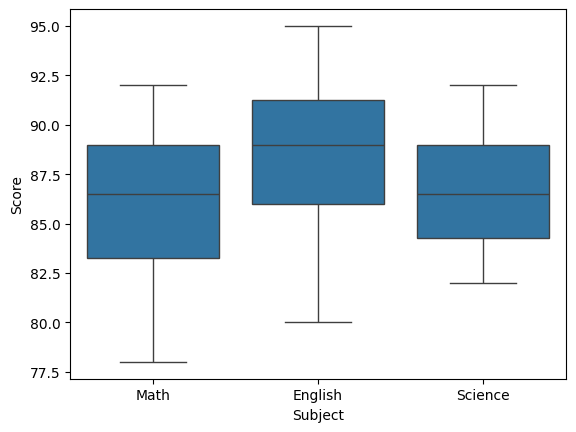

In [5]:
import seaborn as sns
# Why long format is useful: Easy aggregation and visualization

# Calculate average score per subject using groupby in pandas
display(long_scores.groupby(by="Subject")["Score"].mean())

# We use seaborn to create a boxplot of scores by subject. We will learn more about visualization later.
sns.boxplot(data=long_scores, x="Subject", y="Score")

### Example 1: Sales Data by Region and Month


In [6]:
sales_wide = pd.DataFrame(
    {
        "Region": ["North", "South", "East", "West"],
        "January": [15000, 12000, 18000, 14000],
        "February": [16000, 13000, 17500, 15000],
        "March": [18000, 14000, 19000, 16500],
    }
)
display(sales_wide)

,Region,January,February,March
0,North,15000,16000,18000
1,South,12000,13000,14000
2,East,18000,17500,19000
3,West,14000,15000,16500


In [7]:
# Convert to long format
sales_long = sales_wide.melt(
    id_vars="Region",
    var_name="Month",
    value_name="Sales"
)

display(sales_long)

,Region,Month,Sales
0,North,January,15000
1,South,January,12000
2,East,January,18000
3,West,January,14000
4,North,February,16000
5,South,February,13000
6,East,February,17500
7,West,February,15000
8,North,March,18000
9,South,March,14000


In [8]:
# Convert back to wide format
sales_long.pivot(
    index="Region",
    columns="Month",
    values="Sales"
)

Month,February,January,March
Region,,,
East,17500,18000,19000
North,16000,15000,18000
South,13000,12000,14000
West,15000,14000,16500


<Axes: xlabel='Month', ylabel='Sales'>

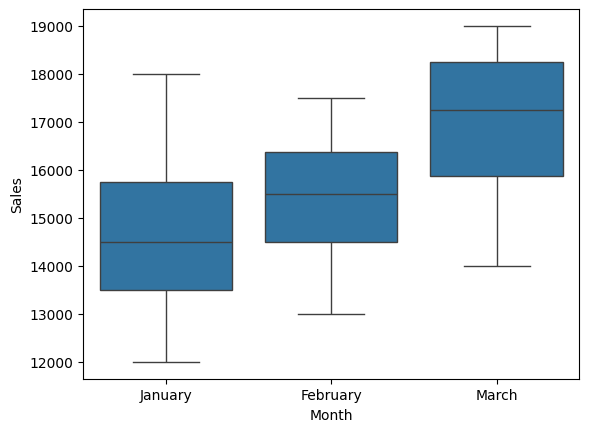

In [9]:
sns.boxplot(data=sales_long, x="Month", y="Sales")

### Example 2: Product Ratings by Customer


In [10]:
ratings_data = {
    "Customer": {
        0: "John",
        1: "Sarah",
        2: "Mike",
        3: "John",
        4: "Sarah",
        5: "Mike",
        6: "John",
        7: "Sarah",
        8: "Mike",
    },
    "Product": {
        0: "Product_A",
        1: "Product_A",
        2: "Product_A",
        3: "Product_B",
        4: "Product_B",
        5: "Product_B",
        6: "Product_C",
        7: "Product_C",
        8: "Product_C",
    },
    "Rating": {0: 5, 1: 4, 2: 5, 3: 3, 4: 5, 5: 4, 6: 4, 7: 4, 8: 3},
}
ratings_long = pd.DataFrame(ratings_data)
display(ratings_long)

,Customer,Product,Rating
0,John,Product_A,5
1,Sarah,Product_A,4
2,Mike,Product_A,5
3,John,Product_B,3
4,Sarah,Product_B,5
5,Mike,Product_B,4
6,John,Product_C,4
7,Sarah,Product_C,4
8,Mike,Product_C,3


In [11]:
# Create wide format
ratings_wide = ratings_long.pivot(
    index="Customer",
    columns="Product",
    values="Rating"
)

display(ratings_wide)

Product,Product_A,Product_B,Product_C
Customer,,,
John,5,3,4
Mike,5,4,3
Sarah,4,5,4


In [12]:
# Convert back to long format
ratings_wide = ratings_wide.reset_index()
ratings_wide.melt(
    id_vars="Customer",
    var_name="Product",
    value_name="Rating"
)

,Customer,Product,Rating
0,John,Product_A,5
1,Mike,Product_A,5
2,Sarah,Product_A,4
3,John,Product_B,3
4,Mike,Product_B,4
5,Sarah,Product_B,5
6,John,Product_C,4
7,Mike,Product_C,3
8,Sarah,Product_C,4


# Using Aggregation with Pivot Tables

Difference between `pivot()` and `pivot_table()` is that the latter allows for aggregation when there are multiple values for the same index/column pair.


In [13]:
# Create a sample dataset
data = {
    "Product": ["Apple", "Banana", "Apple", "Banana", "Apple", "Banana"],
    "Salesperson": ["Alice", "Bob", "Alice", "Bob", "Alice", "Bob"],
    "Sales": [100, 150, 120, 180, 110, 200],
}

sales_long = pd.DataFrame(data)
display(sales_long)

,Product,Salesperson,Sales
0,Apple,Alice,100
1,Banana,Bob,150
2,Apple,Alice,120
3,Banana,Bob,180
4,Apple,Alice,110
5,Banana,Bob,200


In [14]:
# If we try to pivot this data, it will raise an error because there are duplicate entries for the same Product and Salesperson combination.
# sales_pivoted = sales_long.pivot(index='Product', columns='Salesperson', values='Sales')

In [15]:
# We will use pivot_table instead, which can handle duplicates by aggregating them.
# Calculate total sales per product and salesperson
sales_long.pivot_table(
    index="Product",
    columns="Salesperson",
    values="Sales",
    aggfunc="sum"
)

Salesperson,Alice,Bob
Product,,
Apple,330.0,NaN
Banana,NaN,530.0


In [16]:
# Try different aggregation functions
# Calculate mean sales per product and salesperson
sales_long.pivot_table(
    index="Product",
    columns="Salesperson",
    values="Sales",
    aggfunc="mean"
)

Salesperson,Alice,Bob
Product,,
Apple,110.0,NaN
Banana,NaN,176.666667


### Example 4: Adult Database


In [17]:
# Load the adult dataset
adults = pd.read_csv("./data/adult.csv")
adults.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K


In [18]:
adults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3246 entries, 0 to 3245
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              3246 non-null   int64 
 1   workclass        3246 non-null   object
 2   fnlwgt           3246 non-null   int64 
 3   education        3246 non-null   object
 4   educational-num  3246 non-null   int64 
 5   marital-status   3246 non-null   object
 6   occupation       3246 non-null   object
 7   relationship     3246 non-null   object
 8   race             3246 non-null   object
 9   gender           3246 non-null   object
 10  capital-gain     3246 non-null   int64 
 11  capital-loss     3246 non-null   int64 
 12  hours-per-week   3246 non-null   int64 
 13  native-country   3246 non-null   object
 14  income           3246 non-null   object
dtypes: int64(6), object(9)
memory usage: 380.5+ KB


In [19]:
adults.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [27]:
# Create pivot table to analyze average hours worked per week by education level and gender

adults.pivot_table(
    index="education",
    columns="gender",
    values="hours-per-week",
    aggfunc="mean"
)

gender,Female,Male
education,,
10th,31.743590,39.594203
11th,28.705882,36.950617
12th,35.900000,38.190476
1st-4th,46.666667,43.833333
5th-6th,38.375000,39.218750
7th-8th,28.444444,37.370370
9th,39.071429,40.794118
Assoc-acdm,38.657143,47.316667
Assoc-voc,37.000000,44.666667


In [26]:
# Create pivot table to analyze age by occupation and workclass
adults.pivot_table(
    index="occupation",
    columns="workclass",
    values="age",
    aggfunc="mean"
)

workclass,?,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Without-pay
occupation,,,,,,,,
?,38.148515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adm-clerical,NaN,41.942857,37.181818,35.980695,28.000000,57.666667,39.290323,NaN
Armed-Forces,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,NaN
Craft-repair,NaN,41.000000,38.000000,39.110738,41.714286,39.090909,38.111111,NaN
Exec-managerial,NaN,44.454545,46.960000,40.050725,46.763158,49.320000,43.241379,NaN
Farming-fishing,NaN,NaN,50.200000,31.750000,35.600000,46.026316,37.500000,74.0
Handlers-cleaners,NaN,41.333333,24.750000,34.053846,NaN,45.000000,NaN,NaN
Machine-op-inspct,NaN,38.000000,43.000000,36.744898,45.000000,39.500000,48.333333,NaN
Other-service,NaN,33.750000,39.047619,34.168000,50.666667,48.055556,37.166667,19.0
